# 📍 Phase 2-1: 관악구 내 클러스터링 및 후보지 도출

---

**목적**: 관악구 내에서 편의점 입점에 유리한 구체적 후보지를 도출  
**방법**: K-means 클러스터링 → 대중교통 접근성 필터링 → 250m 거리제한 반영  
**결과**: 최종 후보지 4곳 도출

## 1. 데이터 로드 및 관악구 필터링

In [1]:
import pandas as pd
import geopandas as gpd 
from shapely.geometry import Point

In [13]:
서울시버스정류장=pd.read_excel('서울시버스정류소위치정보(20250204).xlsx')

In [15]:
관악구지하철좌표=pd.read_csv('지하철좌표.csv')

In [19]:
import geopandas as gpd

# SHP 파일 불러오기
gdf = gpd.read_file('BND_ADM_DONG_PG.shp')

# 데이터 확인
print(gdf.head())


  BASE_DATE    ADM_CD ADM_NM  \
0  20240630  24010510    충장동   
1  20240630  24010540    동명동   
2  20240630  36680400    안좌면   
3  20240630  36680410    팔금면   
4  20240630  36680420    암태면   

                                            geometry  
0  POLYGON ((192642.941 284096.719, 192642.09 284...  
1  POLYGON ((193270.372 284034.819, 193270.194 28...  
2  MULTIPOLYGON (((113338.23 243273.44, 113342.37...  
3  MULTIPOLYGON (((124370.24 249372.92, 124367.44...  
4  MULTIPOLYGON (((124912 256632.46, 124912.4 256...  


### 관악구 행정동 추출 및 시각화

In [23]:
#관악구행정동만뽑기
토탈=pd.read_csv('토탈.csv')


In [27]:
토탈

,Unnamed: 0,경도,위도,유입인구,유출인구,유동인구,인구,면적,밀도
0,중앙동,126.951336,37.484121,38980,45758,84738,15572,0.39,39928
1,난향동,126.918489,37.461953,41945,12825,54770,14859,0.80,18574
2,서원동,126.933137,37.480135,29907,50325,80232,23690,0.65,36446
3,신원동,126.926746,37.479140,43671,18218,61889,18399,0.55,33453
4,난곡동,126.920547,37.470321,20834,33300,54134,25807,0.96,26882
5,행운동,126.961643,37.480867,47107,53216,100323,29418,0.72,40858
6,인헌동,126.966436,37.472195,22774,29139,51913,25849,1.08,23934
7,낙성대동,126.961381,37.468143,79227,45353,124580,17863,2.27,7869
8,삼성동,126.930529,37.461443,81535,21901,103436,20130,2.66,7568
9,미성동,126.916220,37.474210,37569,47598,85167,30128,1.38,21832


In [35]:
관악구위경도=gdf[gdf['ADM_CD'].str.startswith('11210')]

In [37]:
관악구위경도

,BASE_DATE,ADM_CD,ADM_NM,geometry
1524,20240630,11210520,보라매동,"POLYGON ((193797.271 543840.884, 193798.103 54..."
1526,20240630,11210570,행운동,"POLYGON ((196633.251 542875.139, 196634.34 542..."
1527,20240630,11210580,낙성대동,"POLYGON ((196666.238 542017.532, 196666.204 54..."
1529,20240630,11210620,인헌동,"POLYGON ((197392.7 541771.38, 197400.152 54175..."
1531,20240630,11210640,서원동,"POLYGON ((194643.918 542074.47, 194627.836 542..."
1534,20240630,11210660,서림동,"POLYGON ((195782.362 541293.665, 195780.861 54..."
1539,20240630,11210730,대학동,"POLYGON ((195782.362 541293.665, 195796.162 54..."
1540,20240630,11210780,은천동,"POLYGON ((195022.418 543662.143, 195030.785 54..."
1541,20240630,11210790,성현동,"POLYGON ((196119.541 543561.674, 196123.316 54..."
1542,20240630,11210800,청룡동,"POLYGON ((195253.706 542504.733, 195314.798 54..."


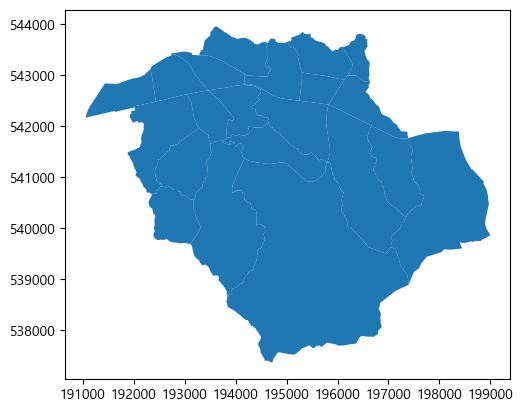

In [39]:
import matplotlib.pyplot as plt

# 지도 시각화
관악구위경도.plot()
plt.show()


## 2. 관악구 내 버스정류장 필터링 (공간결합)

In [45]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

In [47]:
# 버스 정류장 좌표 데이터 불러오기

# 버스 정류장 좌표를 Point 객체로 변환
geometry = [Point(xy) for xy in zip(서울시버스정류장['X좌표'], 서울시버스정류장['Y좌표'])]
gdf_bus_stops = gpd.GeoDataFrame(서울시버스정류장, geometry=geometry)

# 좌표 체계 설정 (WGS84, EPSG:4326)
gdf_bus_stops.set_crs(epsg=4326, inplace=True)




,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입,geometry
0,100000001,1001,종로2가사거리,126.987752,37.569806,중앙차로,POINT (126.98775 37.56981)
1,100000002,1002,창경궁.서울대학교병원,126.996521,37.579433,중앙차로,POINT (126.99652 37.57943)
2,100000003,1003,명륜3가.성대입구,126.998251,37.582580,중앙차로,POINT (126.99825 37.58258)
3,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로,POINT (126.98761 37.56858)
4,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로,POINT (127.00174 37.58624)
...,...,...,...,...,...,...,...
11280,124000334,25995,우성아파트,127.139339,37.550386,일반차로,POINT (127.13934 37.55039)
11281,124000333,25996,우성아파트,127.140046,37.550643,일반차로,POINT (127.14005 37.55064)
11282,124000332,25997,라움포레아파트,127.123596,37.533630,일반차로,POINT (127.1236 37.53363)
11283,124000331,25998,성내시장,127.125497,37.536155,일반차로,POINT (127.1255 37.53615)


In [51]:
# 행정동 경계 데이터를 EPSG:4326으로 변환
관악구위경도 = 관악구위경도.to_crs(epsg=4326)

In [53]:
# 버스 정류장이 행정동에 속해 있는지 확인 (공간 결합)
gdf_bus_stops_in_districts = gpd.sjoin(gdf_bus_stops, 관악구위경도, predicate='within')

# 결과 확인
print(gdf_bus_stops_in_districts.head())


        NODE_ID  ARS_ID         정류소명         X좌표        Y좌표 정류소타입  \
8614  120000435   20936         신대방역  126.913038  37.486605  일반차로   
8615  120000427   20937         신대방역  126.912971  37.486769  일반차로   
8662  119900281   20986  봉천고개관악현대아파트  126.956601  37.491345  마을버스   
8675  120000001   21001     구로디지털단지역  126.902447  37.483935  중앙차로   
8676  120000674   21002     구로디지털단지역  126.902467  37.483977  중앙차로   

                        geometry  index_right BASE_DATE    ADM_CD ADM_NM  
8614   POINT (126.91304 37.4866)         1663  20240630  11210720    조원동  
8615  POINT (126.91297 37.48677)         1663  20240630  11210720    조원동  
8662   POINT (126.9566 37.49135)         1649  20240630  11210540    청림동  
8675  POINT (126.90245 37.48393)         1663  20240630  11210720    조원동  
8676  POINT (126.90247 37.48398)         1663  20240630  11210720    조원동  


In [55]:
gdf_bus_stops_in_districts

,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입,geometry,index_right,BASE_DATE,ADM_CD,ADM_NM
8614,120000435,20936,신대방역,126.913038,37.486605,일반차로,POINT (126.91304 37.4866),1663,20240630,11210720,조원동
8615,120000427,20937,신대방역,126.912971,37.486769,일반차로,POINT (126.91297 37.48677),1663,20240630,11210720,조원동
8662,119900281,20986,봉천고개관악현대아파트,126.956601,37.491345,마을버스,POINT (126.9566 37.49135),1649,20240630,11210540,청림동
8675,120000001,21001,구로디지털단지역,126.902447,37.483935,중앙차로,POINT (126.90245 37.48393),1663,20240630,11210720,조원동
8676,120000674,21002,구로디지털단지역,126.902467,37.483977,중앙차로,POINT (126.90247 37.48398),1663,20240630,11210720,조원동
...,...,...,...,...,...,...,...,...,...,...,...
9150,120900171,21913,서원치안센터.건강보험관악지사,126.929159,37.481993,마을버스,POINT (126.92916 37.48199),1531,20240630,11210640,서원동
9151,120900172,21915,노천강당,126.955328,37.458795,마을버스,POINT (126.95533 37.45879),1539,20240630,11210730,대학동
9152,120900192,21916,신림역4번출구,126.929049,37.483913,마을버스,POINT (126.92905 37.48391),1531,20240630,11210640,서원동
9153,120900203,21919,서원역2번출구.서원동성당앞,126.934466,37.477836,마을버스,POINT (126.93447 37.47784),1531,20240630,11210640,서원동


C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anacond

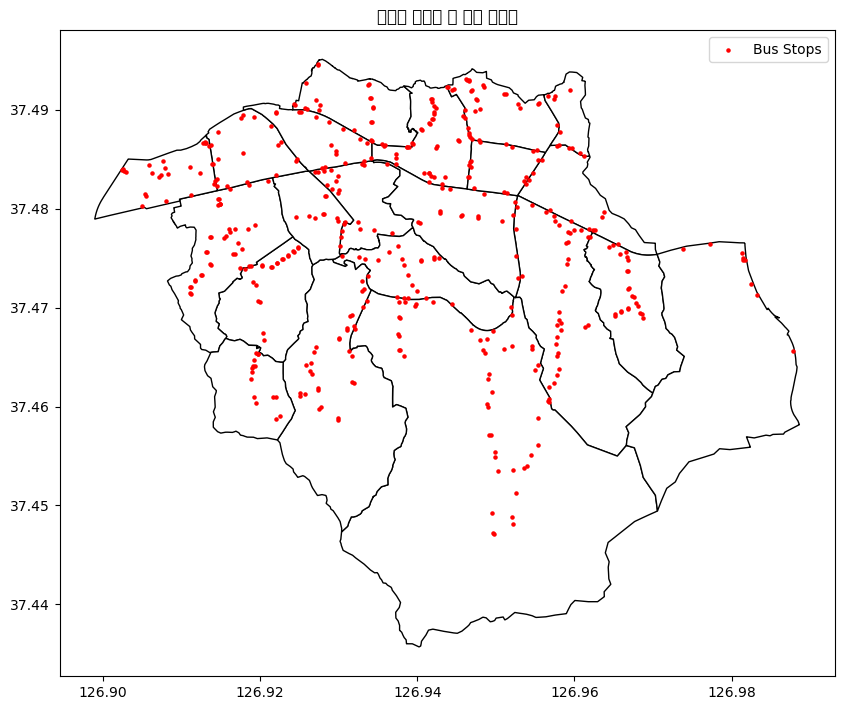

In [387]:
# 지도 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 행정동 경계 그리기
관악구위경도.plot(ax=ax, color='white', edgecolor='black')

# 관악구 버스 정류장 표시
gdf_bus_stops_in_districts.plot(ax=ax, marker='o', color='red', markersize=5, label='Bus Stops')

# 지도에 제목과 범례 추가
plt.title('관악구 행정동 및 버스 정류장')
plt.legend()

# 지도 출력
plt.show()


## 3. 클러스터링 입력 데이터 준비

행정동별 버스정류장 수를 집계하고, 유동인구·밀도와 결합합니다.

In [123]:
지하철역개수=gdf_bus_stops_in_districts['ADM_NM'].value_counts()

In [125]:
지하철역개수.to_frame()

,count
ADM_NM,
대학동,52
은천동,40
미성동,36
낙성대동,35
삼성동,30
성현동,29
조원동,26
보라매동,25
서림동,23


In [131]:
토탈=토탈.set_index('행정동')

In [135]:
클러스터전=pd.merge(토탈,지하철역개수,left_index=True,right_index=True)

In [155]:
클러스터전2=클러스터전[['경도','위도','유동인구','밀도','count']]

In [157]:
클러스터전2

,경도,위도,유동인구,밀도,count
중앙동,126.951336,37.484121,84738,39928,12
난향동,126.918489,37.461953,54770,18574,15
서원동,126.933137,37.480135,80232,36446,21
신원동,126.926746,37.479140,61889,33453,10
난곡동,126.920547,37.470321,54134,26882,22
행운동,126.961643,37.480867,100323,40858,15
인헌동,126.966436,37.472195,51913,23934,23
낙성대동,126.961381,37.468143,124580,7869,35
삼성동,126.930529,37.461443,103436,7568,30
미성동,126.916220,37.474210,85167,21832,36


## 4. K-means 클러스터링

### 4-1. Elbow Method (최적 k 선정)

C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

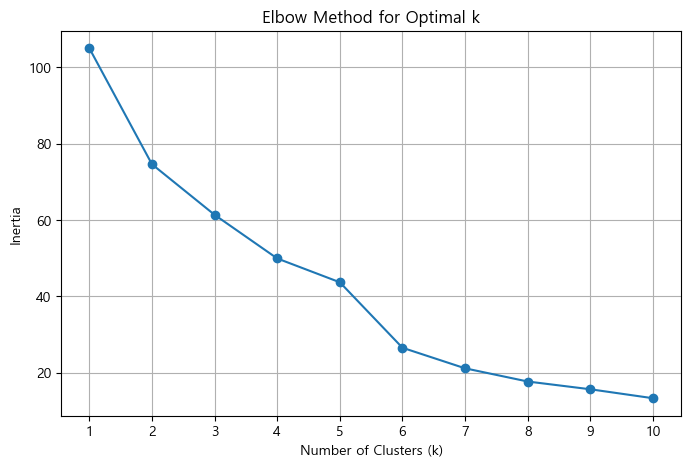

C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [167]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import folium
import numpy as np
# 1. 데이터 로드
df = pd.read_csv('클러스터전2최종.csv')
# 2. 클러스터링에 사용할 변수 선택
features = df[['경도', '위도', '유동인구','밀도', 'count']]
# 3. 데이터 표준화
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# 4. Elbow Method로 최적의 k 찾기
k_values = range(1, 11)
inertia = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(np.arange(1, 11, 1))
plt.grid(True)
plt.show()
# 5. K-Means 클러스터링 수행 (k=6)
kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)
# 6. 클러스터 중심점 확인
centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(centers, columns=['경도', '위도', '유동인구', '밀도', 'count'])
cluster_centers['cluster'] = [0, 1, 2, 3,4,5 ]
# 7. 클러스터 시각화
map_osm = folium.Map(location=[df['위도'].mean(), df['경도'].mean()], zoom_start=13)
colors = ['red', 'blue', 'green','purple','orange','black']
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=6,
        color=colors[row['cluster']],
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['Unnamed: 0']} - 클러스터 {row['cluster']}"
    ).add_to(map_osm)
for idx, row in cluster_centers.iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.Icon(color=colors[int(row['cluster'])], icon='star'),
        popup=f"클러스터 {int(row['cluster'])} 중심"
    ).add_to(map_osm)
map_osm

### 4-2. 시행착오: k=3 시도

> 처음에는 k=3으로 클러스터링을 수행했으나,  
> 관악구 북부 지역이 하나의 군집으로 뭉쳐서 세분화가 부족했습니다.  
> k=6이 행정동 특성을 더 잘 반영하여 최종 선택했습니다.

아래는 k=3 시도 결과입니다 (참고용):

In [203]:
# 5. K-Means 클러스터링 수행 (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
클러스터전2['cluster'] = kmeans.fit_predict(scaled_features)

# 6. 클러스터 중심점 확인
centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(centers, columns=['경도', '위도', '유동인구', '밀도', 'count'])
cluster_centers['cluster'] = [0, 1, 2]

# 7. 클러스터 시각화
map_osm = folium.Map(location=[클러스터전2['위도'].mean(), 클러스터전2['경도'].mean()], zoom_start=13)
colors = ['red', 'blue', 'green']

for idx, row in 클러스터전2.iterrows():
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=6,
        color=colors[row['cluster']],
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['Unnamed: 0']} - 클러스터 {row['cluster']}"
    ).add_to(map_osm)

for idx, row in cluster_centers.iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.Icon(color=colors[int(row['cluster'])], icon='star'),
        popup=f"클러스터 {int(row['cluster'])} 중심"
    ).add_to(map_osm)

map_osm


C:\Users\82104\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 5. 관악구 도로망 및 대중교통 접근성 분석

OSMnx로 관악구 도보 네트워크를 로드하고,  
클러스터 중심점·지하철역·버스정류장의 공간적 관계를 분석합니다.

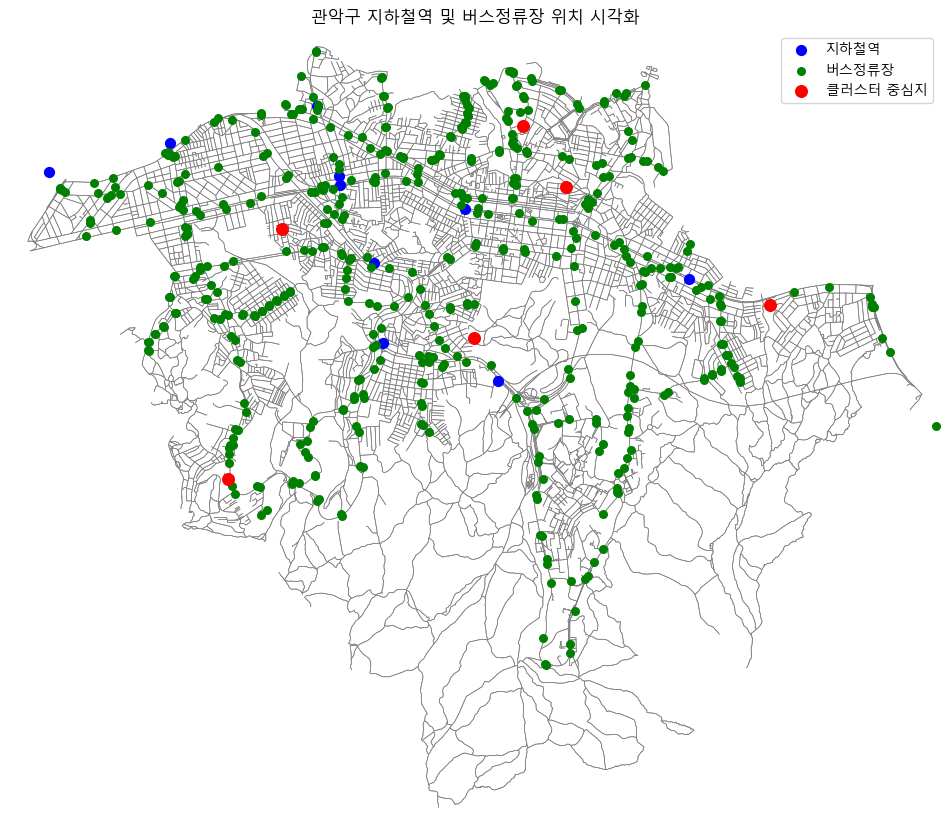

In [177]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. 관악구 도로망 데이터 가져오기
gwanak_graph = ox.graph_from_place('Gwanak-gu, Seoul, South Korea', network_type='walk')

# 2. 보유하신 지하철역 및 버스정류장 좌표 데이터 불러오기
subway_data = pd.read_csv('지하철좌표.csv')
bus_data = pd.read_csv('관악구버스타는곳.csv')

# 3. GeoDataFrame 변환
gdf_subway = gpd.GeoDataFrame(subway_data, geometry=gpd.points_from_xy(subway_data['경도'], subway_data['위도']), crs='EPSG:4326')
gdf_bus = gpd.GeoDataFrame(bus_data, geometry=gpd.points_from_xy(bus_data['X좌표'], bus_data['Y좌표']), crs='EPSG:4326')

cluster_centers = pd.DataFrame({
    '경도': [126.942772, 126.924120, 126.918778, 126.947577, 126.951773, 126.971575],
    '위도': [37.472401, 37.480857, 37.461499, 37.488781, 37.484098, 37.474964]
})
gdf_centers = gpd.GeoDataFrame(cluster_centers, geometry=gpd.points_from_xy(cluster_centers['경도'], cluster_centers['위도']), crs='EPSG:4326')

# 4. 지도 시각화
fig, ax = plt.subplots(figsize=(12, 12))
ox.plot_graph(gwanak_graph, ax=ax, node_size=0, edge_linewidth=0.5, edge_color='gray', show=False)
gdf_subway.plot(ax=ax, color='blue', markersize=50, label='지하철역')
gdf_bus.plot(ax=ax, color='green', markersize=30, label='버스정류장')
gdf_centers.plot(ax=ax, color='red', markersize=70, label='클러스터 중심지') 
plt.legend()
plt.title('관악구 지하철역 및 버스정류장 위치 시각화')
plt.show()


## 6. 클러스터 3 선정 및 250m 버퍼 분석

클러스터 중심에서 300m 이내 대중교통 정거장이 가장 많은 **클러스터 3**을 선정하고,  
편의점 간 **거리제한 규정(250m)** 을 반영하여 출점 가능 영역을 식별합니다.

C:\Users\82104\AppData\Local\Temp\ipykernel_4056\565674588.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


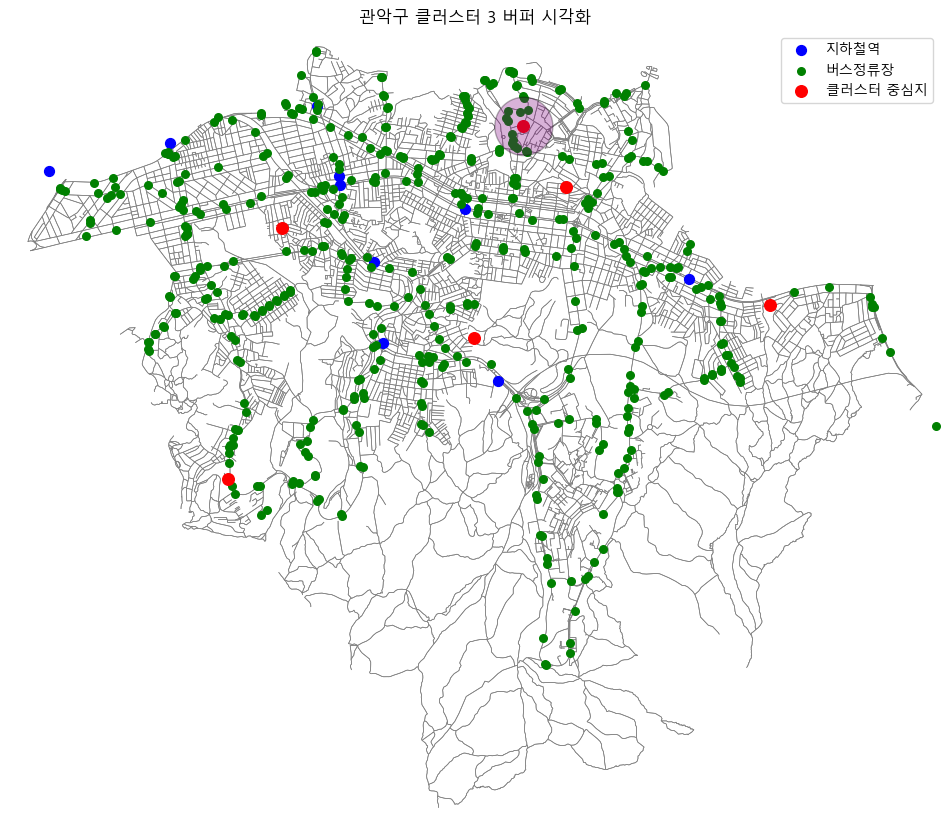

In [209]:
from shapely.geometry import Point
import geopandas as gpd

# 1. 클러스터 3의 중심점 생성 (Point 객체)
cluster_3_center = Point(126.947577, 37.488781)

# 2. GeoDataFrame으로 변환 후 좌표계 변환
gdf_center = gpd.GeoDataFrame(geometry=[cluster_3_center], crs='EPSG:4326')
gdf_center = gdf_center.to_crs(epsg=5179)  # 거리 계산을 위해 UTM-K로 변환

# 3. 250m 버퍼 생성
cluster_3_buffer = gdf_center.buffer(250)

# 4. 다시 EPSG:4326으로 변환
cluster_3_buffer = cluster_3_buffer.to_crs(epsg=4326)

# 5. 지도에 시각화
fig, ax = plt.subplots(figsize=(12, 12))
ox.plot_graph(gwanak_graph, ax=ax, node_size=0, edge_linewidth=0.5, edge_color='gray', show=False)
gdf_subway.plot(ax=ax, color='blue', markersize=50, label='지하철역')
gdf_bus.plot(ax=ax, color='green', markersize=30, label='버스정류장')
gdf_centers.plot(ax=ax, color='red', markersize=70, label='클러스터 중심지')
cluster_3_buffer.plot(ax=ax, facecolor='purple', alpha=0.3, edgecolor='black', label='클러스터 3 - 250m 버퍼')
plt.legend()
plt.title('관악구 클러스터 3 버퍼 시각화')
plt.show()


## 7. 후보 영역 도출

관악구 영역에서 기존 편의점 250m 버퍼를 제외하고,  
대중교통 300m 이내 접근 가능 영역과 교집합하여 후보지를 도출합니다.

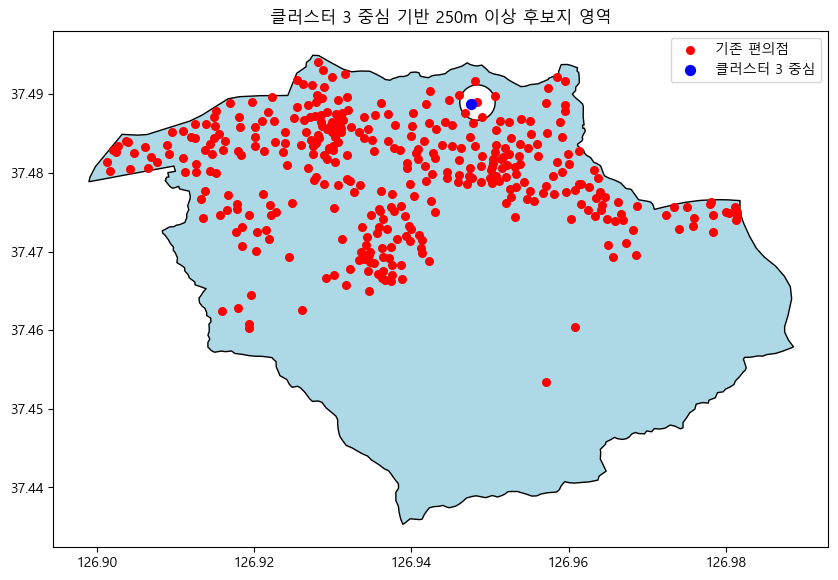

In [193]:
import osmnx as ox
import geopandas as gpd
from geopy.distance import geodesic

# # 1. 클러스터 3 중심점
# cluster_3_center = Point(126.947577, 37.488781)

# # 2. 관악구 편의점 데이터 불러오기
# gdf_stores = gpd.read_file('관악구_행정동_내_편의점.csv', encoding='utf-8')
# # 3. 클러스터 3 중심점에서 가장 가까운 기존 편의점 찾기
# gdf_stores['distance'] = gdf_stores.geometry.distance(cluster_3_center)
nearest_store = gdf_stores.sort_values(by='distance').iloc[0]

# 4. 250m 반경 버퍼 생성
nearest_store_buffer = nearest_store.geometry.buffer(250 / 111320)  # 1도 ≈ 111,320m

# 5. 버퍼 외부의 후보지 영역 생성
candidate_areas = ox.geocode_to_gdf('Gwanak-gu, Seoul, South Korea')
candidate_areas = candidate_areas.overlay(gpd.GeoDataFrame(geometry=[nearest_store_buffer], crs='EPSG:4326'), how='difference')

# 6. 시각화
ax = candidate_areas.plot(color='lightblue', edgecolor='black', figsize=(10, 10))
gdf_stores.plot(ax=ax, color='red', markersize=30, label='기존 편의점')
gpd.GeoSeries([cluster_3_center]).plot(ax=ax, color='blue', markersize=50, label='클러스터 3 중심')
plt.legend()
plt.title('클러스터 3 중심 기반 250m 이상 후보지 영역')
plt.show()


## 7-1. OSMnx 도보 네트워크 기반 편의점 간 도로망 거리 계산

직선거리가 아닌, 실제 도보로 이동 가능한 도로망 거리를 계산합니다.

In [1]:
import geopandas as gpd
import pandas as pd
import folium
import osmnx as ox
from shapely.geometry import Point
from shapely.ops import unary_union, nearest_points

# === 1. 편의점 데이터 및 250m 버퍼 영역 계산 ===
stores = {
    "세븐일레븐 관악드림점": (37.489110, 126.948356),
    "관악힐스점": (37.489003, 126.941912),
    "세븐일레븐 은천로점": (37.487075, 126.944273),
    "세븐일레븐 관악성현점": (37.487061, 126.948683),
    "cu상도약수점": (37.499191, 126.944297),
    "cu숭실대점": (37.495105, 126.958886)
}

store_data = []
for name, (lat, lon) in stores.items():
    store_data.append({'store': name, 'geometry': Point(lon, lat)})
gdf_stores = gpd.GeoDataFrame(store_data, crs="EPSG:4326")

gdf_stores_utm = gdf_stores.to_crs("EPSG:32652")
gdf_stores_utm["buffer_250m"] = gdf_stores_utm.geometry.buffer(250)
store_buffers_union = unary_union(gdf_stores_utm["buffer_250m"].tolist())

# === 2. 관악구 영역에서 편의점 250m 버퍼를 제외한 영역 ===
candidate_area = ox.geocode_to_gdf('Gwanak-gu, Seoul, South Korea')
candidate_area_utm = candidate_area.to_crs("EPSG:32652")
candidate_area_filtered = candidate_area_utm.geometry.iloc[0].difference(store_buffers_union)

# === 3. 버스, 지하철 데이터 및 300m 버퍼 영역 계산 ===
subway = pd.read_csv('지하철좌표.csv')
bus = pd.read_csv('관악구버스타는곳.csv')

gdf_subway = gpd.GeoDataFrame(subway, geometry=gpd.points_from_xy(subway['경도'], subway['위도']), crs='EPSG:4326')
gdf_bus = gpd.GeoDataFrame(bus, geometry=gpd.points_from_xy(bus['X좌표'], bus['Y좌표']), crs='EPSG:4326')

gdf_subway_utm = gdf_subway.to_crs("EPSG:32652")
gdf_subway_utm["buffer_300m"] = gdf_subway_utm.geometry.buffer(300)
gdf_bus_utm = gdf_bus.to_crs("EPSG:32652")
gdf_bus_utm["buffer_300m"] = gdf_bus_utm.geometry.buffer(300)

transit_buffers_union = unary_union(list(gdf_subway_utm["buffer_300m"]) + list(gdf_bus_utm["buffer_300m"]))

# === 4. 후보 영역(관악구 영역 ∩ 교통 접근영역) ===
final_candidate_area = candidate_area_filtered.intersection(transit_buffers_union)

# === 5. cluster3 기준으로 가장 가까운 후보점 찾기 ===
cluster_3_center = Point(126.947577, 37.488781)
cluster_3_center_utm = gpd.GeoSeries([cluster_3_center], crs="EPSG:4326").to_crs("EPSG:32652").iloc[0]
candidate_point_utm = nearest_points(cluster_3_center_utm, final_candidate_area)[1]
candidate_point = gpd.GeoSeries([candidate_point_utm], crs="EPSG:32652").to_crs("EPSG:4326").iloc[0]

# === 6. Folium 지도에 결과 표시 ===
m = folium.Map(location=[cluster_3_center.y, cluster_3_center.x], zoom_start=15)

for idx, row in gdf_stores.to_crs("EPSG:4326").iterrows():
    folium.Marker(location=[row.geometry.y, row.geometry.x], popup=row["store"],
                  icon=folium.Icon(color="red", icon="info-sign")).add_to(m)

folium.Marker(location=[cluster_3_center.y, cluster_3_center.x], popup="Cluster3 Center",
              icon=folium.Icon(color="blue", icon="star")).add_to(m)

folium.Marker(location=[candidate_point.y, candidate_point.x], popup="Candidate Location",
              icon=folium.Icon(color="green", icon="ok-sign")).add_to(m)

final_candidate_area_gdf = gpd.GeoDataFrame(geometry=[final_candidate_area], crs="EPSG:32652").to_crs("EPSG:4326")
folium.GeoJson(final_candidate_area_gdf.__geo_interface__, name="Candidate Area",
               style_function=lambda x: {"color": "green", "weight": 2, "fillOpacity": 0.2}).add_to(m)

transit_buffers_gdf = gpd.GeoDataFrame(geometry=[transit_buffers_union], crs="EPSG:32652").to_crs("EPSG:4326")
folium.GeoJson(transit_buffers_gdf.__geo_interface__, name="Transit Buffers (300m)",
               style_function=lambda x: {"color": "purple", "weight": 1, "fillOpacity": 0.1}).add_to(m)

folium.LayerControl().add_to(m)
m

세븐일레븐 관악드림점: 0 m
관악힐스점: 1061 m
세븐일레븐 은천로점: 556 m
세븐일레븐 관악성현점: 338 m
cu상도약수점: 1485 m
cu숭실대점: 1658 m


# 14p 사진 

In [26]:
import geopandas as gpd
import pandas as pd
import folium
import osmnx as ox
from shapely.geometry import Point
from shapely.ops import unary_union, nearest_points

# === 1. 편의점 데이터 및 250m 버퍼 영역 계산 ===
# 편의점 위치 (값은 (위도, 경도) 순서)
stores = {
    "세븐일레븐 관악드림점": (37.489110, 126.948356),
    "관악힐스점": (37.489003, 126.941912),
    "세븐일레븐 은천로점": (37.487075, 126.944273),
    "세븐일레븐 관악성현점": (37.487061, 126.948683),
    "cu상도약수점": (37.499191, 126.944297),
    "cu숭실대점": (37.495105, 126.958886)
}

# GeoDataFrame 생성 (Point는 (경도, 위도) 순서)
store_data = []
for name, (lat, lon) in stores.items():
    store_data.append({'store': name, 'geometry': Point(lon, lat)})
gdf_stores = gpd.GeoDataFrame(store_data, crs="EPSG:4326")

# UTM으로 변환하여 250m 버퍼 생성 (미터 단위 계산)
gdf_stores_utm = gdf_stores.to_crs("EPSG:32652")
gdf_stores_utm["buffer_250m"] = gdf_stores_utm.geometry.buffer(250)

# 모든 편의점의 250m 버퍼 합집합
store_buffers_union = unary_union(gdf_stores_utm["buffer_250m"].tolist())

# === 2. 관악구 영역에서 편의점 250m 버퍼를 제외한 영역 ===
# osmnx로 관악구 영역 추출 (관악구, Seoul, South Korea)
candidate_area = ox.geocode_to_gdf('Gwanak-gu, Seoul, South Korea')
candidate_area_utm = candidate_area.to_crs("EPSG:32652")
# 관악구 영역에서 편의점 버퍼들을 제외
candidate_area_filtered = candidate_area_utm.geometry.iloc[0].difference(store_buffers_union)

# === 3. 버스, 지하철 데이터 및 300m 버퍼 영역 계산 ===
# CSV 파일 읽기 (컬럼명이 맞는지 확인)
subway = pd.read_csv('지하철좌표.csv')       # 컬럼: '경도', '위도'
bus = pd.read_csv('관악구버스타는곳.csv')       # 컬럼: 'X좌표', 'Y좌표'

# 지하철 GeoDataFrame 생성
gdf_subway = gpd.GeoDataFrame(
    subway, 
    geometry=gpd.points_from_xy(subway['경도'], subway['위도']),
    crs='EPSG:4326'
)
# 버스 GeoDataFrame 생성
gdf_bus = gpd.GeoDataFrame(
    bus, 
    geometry=gpd.points_from_xy(bus['X좌표'], bus['Y좌표']),
    crs='EPSG:4326'
)

# UTM 변환 및 300m 버퍼 생성
gdf_subway_utm = gdf_subway.to_crs("EPSG:32652")
gdf_subway_utm["buffer_300m"] = gdf_subway_utm.geometry.buffer(300)

gdf_bus_utm = gdf_bus.to_crs("EPSG:32652")
gdf_bus_utm["buffer_300m"] = gdf_bus_utm.geometry.buffer(300)

# 버스와 지하철 버퍼들의 합집합
transit_buffers_union = unary_union(list(gdf_subway_utm["buffer_300m"]) + list(gdf_bus_utm["buffer_300m"]))

# === 4. 후보 영역(관악구 영역 ∩ 교통 접근영역) ===
# 교통 접근성이 확보된 영역과의 교집합
final_candidate_area = candidate_area_filtered.intersection(transit_buffers_union)
# final_candidate_area: 편의점 250m 버퍼 외부, 관악구 내, 버스/지하철 300m 이내 영역

# === 5. cluster3 기준으로 가장 가까운 후보점 찾기 ===
cluster_3_center = Point(126.947577, 37.488781)
# UTM 변환
cluster_3_center_utm = gpd.GeoSeries([cluster_3_center], crs="EPSG:4326").to_crs("EPSG:32652").iloc[0]
# 후보 영역에서 cluster3에 가장 가까운 점 구하기
# (최단 거리의 점은 polygon에 대한 "nearest point"로 계산)
candidate_point_utm = nearest_points(cluster_3_center_utm, final_candidate_area)[1]

# UTM -> EPSG:4326 (Folium용)
candidate_point = gpd.GeoSeries([candidate_point_utm], crs="EPSG:32652").to_crs("EPSG:4326").iloc[0]

# === 6. Folium 지도에 결과 표시 ===
# 지도 중심을 cluster3로 설정
m = folium.Map(location=[cluster_3_center.y, cluster_3_center.x], zoom_start=15)

# 편의점 마커 추가 (EPSG:4326)
for idx, row in gdf_stores.to_crs("EPSG:4326").iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row["store"],
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)

# cluster3 마커 (파란색 별)
folium.Marker(
    location=[cluster_3_center.y, cluster_3_center.x],
    popup="Cluster3 Center",
    icon=folium.Icon(color="blue", icon="star")
).add_to(m)

# 후보 위치 마커 (초록색 체크)
folium.Marker(
    location=[candidate_point.y, candidate_point.x],
    popup="Candidate Location",
    icon=folium.Icon(color="green", icon="ok-sign")
).add_to(m)

# 후보 영역(다각형) 표시: UTM에서 계산된 영역을 EPSG:4326으로 변환하여 GeoJson 추가
final_candidate_area_gdf = gpd.GeoDataFrame(geometry=[final_candidate_area], crs="EPSG:32652").to_crs("EPSG:4326")
folium.GeoJson(
    final_candidate_area_gdf.__geo_interface__,
    name="Candidate Area",
    style_function=lambda x: {"color": "green", "weight": 2, "fillOpacity": 0.2}
).add_to(m)

# (선택사항) 버스/지하철 300m 버퍼 영역을 지도에 추가하고 싶다면:
transit_buffers_gdf = gpd.GeoDataFrame(geometry=[transit_buffers_union], crs="EPSG:32652").to_crs("EPSG:4326")
folium.GeoJson(
    transit_buffers_gdf.__geo_interface__,
    name="Transit Buffers (300m)",
    style_function=lambda x: {"color": "purple", "weight": 1, "fillOpacity": 0.1}
).add_to(m)

# Layer Control 추가
folium.LayerControl().add_to(m)

# 지도 저장 또는 출력
m.save("candidate_map.html")
m
